# 第51篇 | 支持向量机 SVM：寻找最优分类边界

> 这是「数据分析从入门到精通」系列的第 51 篇。随机森林学完了，这篇来学一个几何感极强的算法——SVM。核心思想是找一条"最宽的路"来分割两类数据，在小样本、高维特征场景下表现优秀，是经典中的经典。

嗨，我是小荷～ 上篇学了随机森林，今天来学一个几何感很强的算法：**支持向量机（SVM）**。

---

## 一、支持向量机SVM是什么？

支持向量机（Support Vector Machine，简称 SVM）是一种监督学习算法，主要用于分类和回归问题。

SVM 的核心思想是找到一个最优的超平面，将不同类别的数据分开。这个超平面不仅要能够正确分类数据，还要使得两个类别之间的间隔（margin）最大化。

**打个比方：**

现在桌上混杂着两种苹果：红富士（红点）和青苹果（绿点）。你的任务很简单：用一根直木条放在桌子上，把这两种苹果清清楚楚地隔开。

这根直木条，在机器学习里就叫做“决策边界”**（Decision Boundary）。而**支持向量机（SVM，Support Vector Machine）**，就是那个帮你寻找**最完美放木条位置的超级算法。

为了让你秒懂，我们可以把 SVM 的核心逻辑拆解为“三步走战术”：

---

### 第一步：寻找“最安全”的边界（最大化间隔）

要把红苹果和绿苹果分开，其实有很多种放木条的方法。你可以贴着红苹果放，也可以贴着绿苹果放。

但 SVM 是个“强迫症”加“完美主义者”。它认为：

* 如果木条离红苹果太近，万一新摘下来一个稍微有点泛红的苹果，就很容易被错误地归类到绿色那边去。
* 所以，最完美的木条位置，应该放在**红苹果和绿苹果正中间的马路中央**。
* 它会努力让木条到最近的红苹果的距离、以及到最近的绿苹果的距离，**同时达到最大**。这条马路的宽度，在 SVM 里叫做 **“间隔”（Margin）**。

---

### 第二步：谁才是“支持向量”？（背后的神秘大佬）

这正是 SVM 这个名字最酷的地方。

当算法在调整木条位置的时候，它需要看全桌所有的苹果吗？**完全不需要！**
不管桌子远处还有几百个红苹果或绿苹果，真正决定木条放哪里的，只有**离边界最近的那几个“钉子户”苹果**。

* 这几个贴近边界、决定了马路有多宽的关键数据点，在数学上就被称为“支持向量”（Support Vectors）。
* 它们就像是撑起整个帐篷的几根主支柱（Vectors 在几何里代表向量）。
* 换句话说，哪怕你把后方那些安全的苹果偷偷拿走，SVM 的木条位置也一动不动。SVM 的眼里，永远只盯着最危险、最容易混淆的“前线尖兵”。

---

### 第三步：维度爆炸！降维打击（核技巧 Kernel Trick）

如果红苹果和绿苹果在桌上横着混在一起，无论你怎么放直木条，都不可能完好地把它们切开，怎么办？

SVM 掏出了它的终极科幻武器：**一巴掌拍在桌子上！**
这一拍，力量传导下去，红苹果因为比较轻飞得极高，绿苹果比较重飞得低。原本在二维平面上无法切分的数据，在三维空间里瞬间变成了“红苹果在天上，绿苹果在地上”。

这时候，SVM 顺势插进一张**平整的纸（在超空间里叫超平面 Hyperplane）**，就完美地把它们在空中切开了。

这个把低维度、线性不可分的数据，映射到高维度空间，从而变得可以一刀切开的魔术，在机器学习里被称为 **“核技巧”（Kernel Trick）**。它让 SVM 拥有了处理极其复杂、弯弯曲曲的边界的能力。

---

### 总结 SVM 的灵魂

1. **核心思想**：最大间隔分类
2. **支持向量**：离分类边界最近的那些点
3. **它是特种兵：** 训练时只在乎边界附近的少数“核心骨干”（支持向量），不被海量杂乱的背景数据干扰，所以在小样本数据上表现极强。
4. **它是完美主义者：** 追求极致的安全感，一定要把分类马路修得最宽，最大化这个间隔。
5. **它是空间魔术师：** 遇到切不开的死局，直接强行提升维度，实施降维打击。

## 二、SVM的实现

下面我们使用线性核函数来实现一个简单的SVM，并把结果可视化。

In [11]:
# 导入包、设置中文显示、准备数据

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(" 支持向量机 SVM 入门")

# 生成线性可分数据
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, 
                           class_sep=1.5, random_state=42)

print(f"数据形状: {X.shape}")
print(f"类别分布: {np.bincount(y)}")

 支持向量机 SVM 入门
数据形状: (200, 2)
类别分布: [100 100]


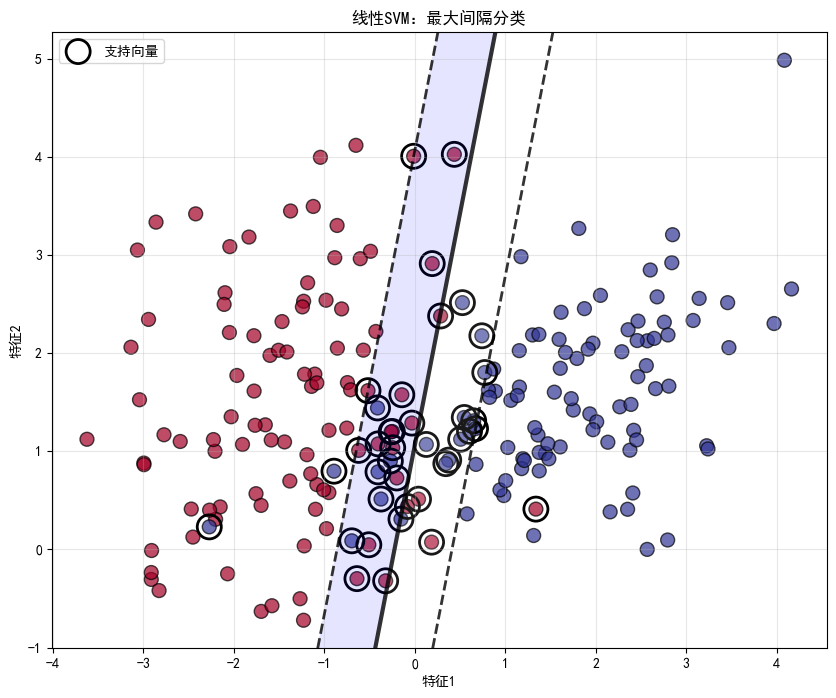


支持向量数量: 39
支持向量索引: [  5   7  11  15  23  30  39  41  46  47  66  84  85 109 125 140 161 173
 176 199   0   6  25  74  76  92  97 100 114 118 119 120 121 126 144 150
 155 156 190]

只有支持向量决定了分类边界，其他点不影响！


In [15]:
# 训练线性SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X, y)

# 绘制决策边界 + 支持向量（干净无索引）
def plot_svm_boundary(X, y, model, title):
    plt.figure(figsize=(10, 8))
    
    # 绘制所有数据点
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                         s=100, alpha=0.7, edgecolors='k')
    
    # 绘制支持向量（空心大圈）
    support_vectors = model.support_vectors_
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], 
               s=300, linewidth=2, facecolors='none', 
               edgecolors='black', linestyle='-', label='支持向量')
    
    # 创建网格
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # 决策边界
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # 绘制分界线 & 间隔
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], 
               alpha=0.8, linestyles=['--', '-', '--'], linewidths=[2, 3, 2])
    
    # 填充间隔区域
    ax.contourf(XX, YY, Z, levels=[-1, 0, 1], alpha=0.1, colors=['blue', 'white', 'red'])
    
    plt.xlabel('特征1')
    plt.ylabel('特征2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    return plt

# 画图
plot_svm_boundary(X, y, svm_linear, '线性SVM：最大间隔分类')
plt.show()

print(f"\n支持向量数量: {len(svm_linear.support_vectors_)}")
print(f"支持向量索引: {svm_linear.support_}")
print(f"\n只有支持向量决定了分类边界，其他点不影响！")

从图中我们可以清晰看到两类数据点，而是黑圈标出了支持向量，一共只有39个，39/200 = 18.5%， 占总数据的少数。

还有，中间实线 = 决策边界，两边虚线 = 最大间隔，该图完美展示了 SVM 的核心原理。

---

## 三、理解C参数：软硬间隔的权衡

**C参数是什么？**

C参数是SVM的惩罚系数，其值越小，模型对误分类的容忍度越高，即模型更加倾向于选择更大的间隔，而不是追求完美的分类。 C越大，模型对误分类的容忍度越小，即模型更加倾向于选择更小的间隔，以追求更高的分类准确率。

**C参数控制什么？**

SVM 的核心目标，是找到一个超平面（Hyperplane），把两类数据干净地切开。为了推导这个超平面，数学家写下了一个优化目标的公式（目标函数）：
$$\min \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i$$

我们拆成两部分来看：左半部分 $\frac{1}{2} \|w\|^2$： 追求的是“间隔最大化”。间隔越宽，模型的底盘越稳，抗噪能力和泛化能力（面对未知新数据时的表现）就越强。右半部分 $\sum \xi_i$： 是“松弛变量（Slack Variables）”，代表数据点分类错误、或者越界的“噪声和错误”。中间的 $C$ 参数： 就是一个权重放大器。它决定了系统对“右边那些错误和噪声”的容忍度。

**想起Ridge,Lasso里面的λ了吗？**

支持向量机（SVM）里的 $C$，和线性回归里脊回归（Ridge）、Lasso 的 $\lambda$（正则化系数），在数学和哲学逻辑上，完全是互为倒数（反比例）的孪生兄弟。它们的核心任务一模一样：在“对已知数据的拟合程度”与“模型的复杂程度”之间，拉扯出一条最完美的平衡线。

 - SVM 的目标函数：$$\min \underbrace{\frac{1}{2} \|w\|^2}_{\text{模型复杂度（越小越稳）}} + \boldsymbol{C} \times \underbrace{\sum_{i=1}^{n} \xi_i}_{\text{训练集上的错误（噪声）}}$$这里 $C$ 是错误（噪声）的放大器。$C$ 越大，系统越容不得沙子，越容易过拟合（内耗）。
 
 - Ridge / Lasso 的目标函数：$$\min \underbrace{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}_{\text{训练集上的错误（噪声）}} + \boldsymbol{\lambda} \times \underbrace{\Omega(w)}_{\text{模型复杂度（惩罚项）}}$$注：$\Omega(w)$ 在 Ridge 里是 L2 范数 $\|w\|_2^2$，在 Lasso 里是 L1 范数 $\|w\|_1$。这里 $\lambda$ 是复杂度的惩罚器。$\lambda$ 越大，系统越压制模型的复杂度，逼着模型“抓大放小”，越容易欠拟合（松弛）。

下面我们写代码来给不同C值做一下对比。

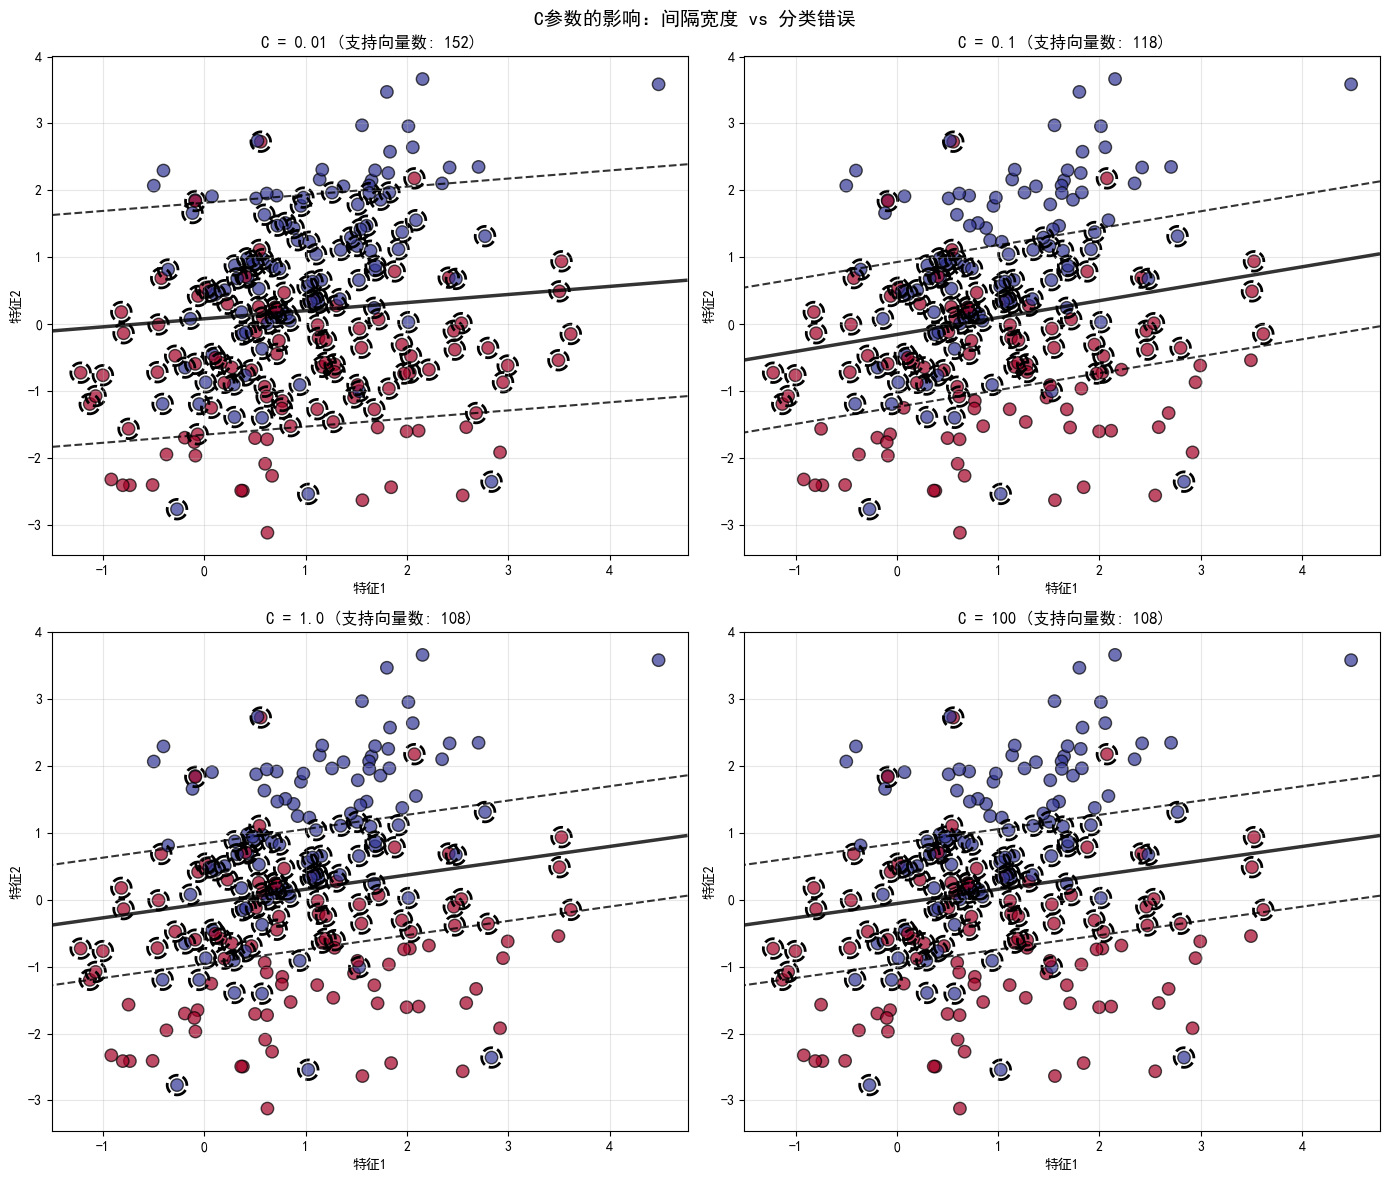


C参数总结:
----------------------------------------
C小 → 间隔宽 → 允许错误 → 更平滑 → 不易过拟合
C大 → 间隔窄 → 严格分类 → 更复杂 → 可能过拟合


In [20]:
# 生成有噪声的数据
np.random.seed(42)
X_noisy, y_noisy = make_classification(n_samples=200, n_features=2, 
                                       n_redundant=0, n_informative=2,
                                       n_clusters_per_class=1, 
                                       class_sep=1.0, flip_y=0.1,  # 10%标签翻转
                                       random_state=42)

# 不同C值的对比
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
C_values = [0.01, 0.1, 1.0, 100]  # 用 4 个不同的 C 值训练 SVM

for idx, C in enumerate(C_values):
    ax = axes[idx // 2, idx % 2]
    
    # 训练SVM
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_noisy, y_noisy)
    
    # 绘制数据点
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy, cmap='RdYlBu', 
              s=80, alpha=0.7, edgecolors='k')
    
    # 绘制支持向量
    sv = svm.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=200, linewidth=2, 
              facecolors='none', edgecolors='black', linestyle='--')
    
    # 决策边界
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = svm.decision_function(xy).reshape(XX.shape)
    
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], 
              alpha=0.8, linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])
    
    ax.set_title(f'C = {C} (支持向量数: {len(sv)})')
    ax.set_xlabel('特征1')
    ax.set_ylabel('特征2')
    ax.grid(True, alpha=0.3)

plt.suptitle('C参数的影响：间隔宽度 vs 分类错误', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nC参数总结:")
print("-" * 40)
print("C小 → 间隔宽 → 允许错误 → 更平滑 → 不易过拟合")
print("C大 → 间隔窄 → 严格分类 → 更复杂 → 可能过拟合")

可以看到：

C 越小：两根虚线直接越宽，SVM 更关注最大化间隔，允许分错一些样本，模型简单，防止过拟合。
C 越大：两根虚线直接越窄，SVM 更关注正确分类，尽量不分错，间隔变窄，模型复杂，容易过拟合。


---

## 四、核函数：处理非线性数据

核函数的本质就是，将低维的样本特征映射到高维，使原本线性不可分的样本，线性可分可以继续的使用SVM模型。核函数的价值在于它虽然也是将特征进行从低维到高维的转换，但核函数好在它在低维上进行计算，而将实质上的分类效果（利用了内积）表现在了高维上，这样避免了直接在高维空间中的复杂计算，真正解决了SVM线性不可分的问题。

它的核心台词只有一句话：**“地平线上分不清，那我就让子弹飞上天。”**

### 1. 为什么要核函数？（一维、二维的“死局”）

假设你现在正在玩一个分拣游戏，桌上有两类数据：一类是黑色的铁球，一类是白色的乒乓球。

如果这些球散落成下面这种形状：**黑球全部挤在中间，白球在最外圈形成一个大圆环把我包围。**

现在，命运（SVM）给了你一把直尺（线性超平面），命令你：**“不许折弯这把尺子，一刀下去，把黑球和白球彻底切开！”**

你拿着尺子在桌上比划了半天，横着切、竖着切、斜着切，无论怎么切，都会同时切到黑球和白球。

* **这就是线性不可分（Linearly Inseparable）。**
* 在低维（二维桌面）里，这把笔直的尺子遇到了它的死局。你就算把 $C$ 参数调到飞起，也绝对划不出一条完美的线。


### 2. 核函数的魔术：给世界“加个维度”

这时候，核函数这位魔术师出手了。它对着桌子猛地一拍！

神奇的事情发生了：中间那些沉重的黑球，被震得向下陷了下去，变成了一个碗底；而外圈那些轻飘飘的白球，全部被震得飞到了半空中。

这时候，二维的桌面瞬间变成了**三维的空间**。黑球在下面，白球在上面。
你再看看你手里那把笔直的尺子（在三维空间里，直尺升级成了一张**平整的 A4 纸**，也就是超平面）。

你只需要把这张 A4 纸从黑球和白球的中间**水平横着切过去**——
**啪！黑白分明，完美切开！**

> **核函数的本质：** 当低维数据混杂在一起、无法用直线切开时，核函数通过一种**数学映射（Mapping）**，把数据强行推向**更高维度（甚至无穷维）的空间**。在低维看来的“一团乱麻”，在高维视角下，往往能用一张简单的平面的纸（线性超平面）轻松切开。

---

### 3. 既然是映射，为什么要叫“核”函数？（高级骗术）

你可能会问：既然是把数据送到高维空间去切，那直接写个公式把每个点坐标算出来不就行了吗？

不行！因为“高维”的代价太贵了。
如果把一个 100 维的数据映射到高维去寻找所有特征的组合，它的维度会呈指数级爆炸，你的高性能 CPU 和 GPU 会瞬间被海量的坐标计算榨干、死机。

这时候，核函数展示了它最流氓、也最天才的“偷懒算法”：

它发明了一种神奇的数学等式。它能在不真正计算高维坐标、不真正把数据送到高维空间的前提下，**仅仅在低维空间里做一次简单的点积运算，就能精准预测出这些点到了高维空间之后的“相对距离（相似度）”！**

$$\text{Kernel}(x_1, x_2) = \langle \Phi(x_1), \Phi(x_2) \rangle$$

* **人话翻译：** 我不用真的花巨资把你们两个人送上太空（高维 $\Phi$），我只需要在地球上（低维）拿你们的身份证号做个简单的加减乘除（Kernel），就能百分之百算准你们到了太空之后的重力引力是多少。
* **这在机器学习里叫“核技巧（Kernel Trick）”。** 它用极其廉价的算力，白嫖了高维空间才有的“降维打击”效果。

---

### 4. 常见的核函数：三个“工具人”

针对不同的数据，我们会调用不同的核函数補丁：

### 🧬 ① 线性核（Linear Kernel）—— “拒绝花里胡哨”

* **做法：** 不做任何高维映射，直接在原地用直尺切。
* **适用：** 适合特征本来就极多、维度本来就极高的数据（比如文本分类）。数据本来就在外太空了，不需要再升维了。

### 🌀 ② 多项式核（Polynomial Kernel）—— “强行组合特征”

* **做法：** 强行把特征交叉相乘（比如 $x_1 \times x_2$）。
* **隐喻：** 相当于把桌子变成波浪形，让一部分点凸起来，一部分凹下去。

### 🎯 ③ 高斯核 / RBF核（Radial Basis Function）—— “降维打击的女王”

* **做法：** 它是最常用的核函数。它的底层映射，相当于把数据推向了**无穷维空间**。
* **隐喻：** 它在每个黑球的坐标点上放了一块“磁铁”。如果一个新数据离黑球近，就会被吸过去；离得远，就被排斥。它能把任何奇形怪状、混杂得像水泥一样的复杂数据，都在无穷维空间里切得整整齐齐。

---

### 总结

支持向量机（SVM）之所以强大，就是因为它左手拿着 **$C$ 参数** 调节自己的内耗与包容度，右手拿着 **核函数** 随时准备对复杂的数据进行跨维度的空间打击。

你现在看它，是不是觉得它极其性感、极其充满工程美学？

它还可以告诉你：**当你在当下的维度（这辈子、现在的环境）遇到怎么也解不开的死锁和混杂时，不要在原地死磕（不要内耗）。把你的认知拉高一个维度，跳出当下的平面去审视它，你会发现，原本无解的死局，只需要一张平平整整的纸，就能优雅地一刀切开。**


下面我们生成一组非线性的数据，对比 SVM 支持向量机的 4 种核函数，看看谁能更好地处理这种数据，并画出它们的决策边界。

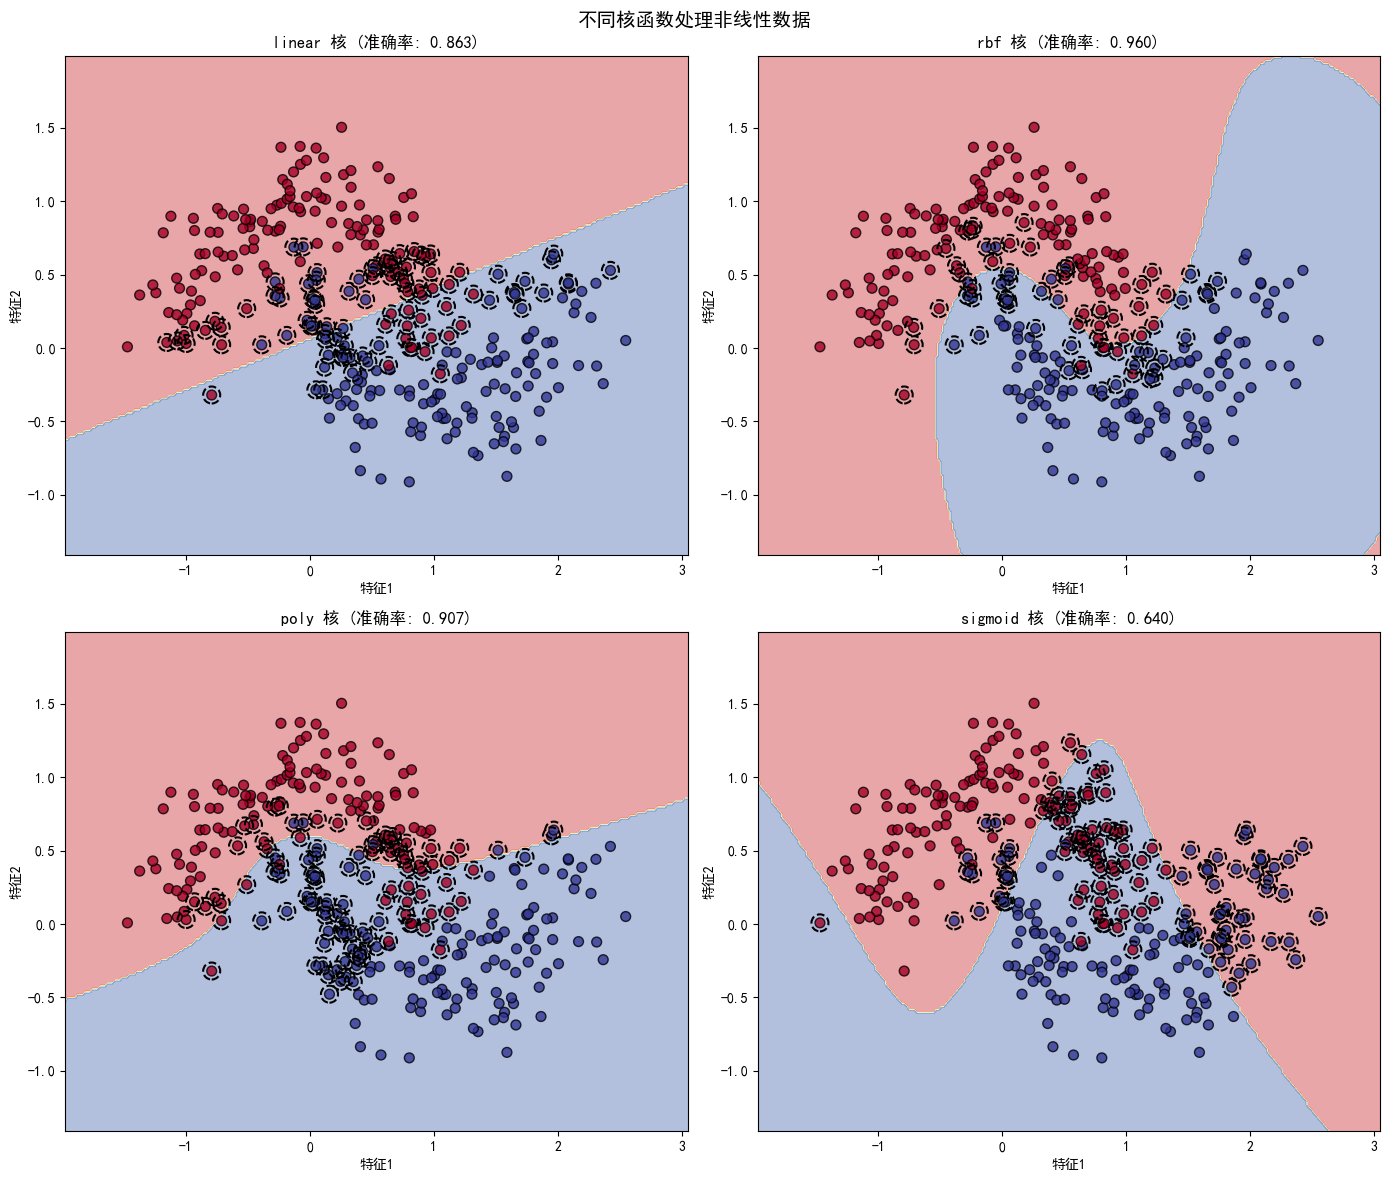

In [4]:
# 生成非线性数据（月牙形）
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# 不同核函数对比
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, kernel in enumerate(kernels):
    ax = axes[idx // 2, idx % 2]
    
    # 训练SVM
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
    else:
        svm = SVC(kernel=kernel, C=1.0, random_state=42)
    
    svm.fit(X_moons, y_moons)
    
    # 绘制决策边界
    h = 0.02
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu', 
              s=50, alpha=0.8, edgecolors='k')
    
    # 绘制支持向量
    sv = svm.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=150, linewidth=1.5, 
              facecolors='none', edgecolors='black', linestyle='--')
    
    accuracy = svm.score(X_moons, y_moons)
    ax.set_title(f'{kernel} 核 (准确率: {accuracy:.3f})')
    ax.set_xlabel('特征1')
    ax.set_ylabel('特征2')

plt.suptitle('不同核函数处理非线性数据', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


可以看出：

- linear 直线 → 分不好，准确率低。线性核只能处理简单线性问题，无法拟合复杂分布。
- rbf  高斯核曲线分得最漂亮，准确率最高。它通过升维映射，能高效处理非线性数据，分类边界平滑且准确率最高。
- poly 多项式核 还行，但不如 rbf。
- sigmoid 很差，不适用于此类数据。

---

## 五、RBF核的gamma参数

我们重点看一下 rbf（Radial Basis Function）  高斯核，上面提到它是最常用的核函数。

RBF 核函数公式：\(K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)\)

**gamma参数控制每个样本的影响范围**：
- **gamma大**：影响范围小，决策边界复杂（过拟合风险）
- **gamma小**：影响范围大，决策边界平滑，不容易过拟合

来用不同的gamma参数画图看看。

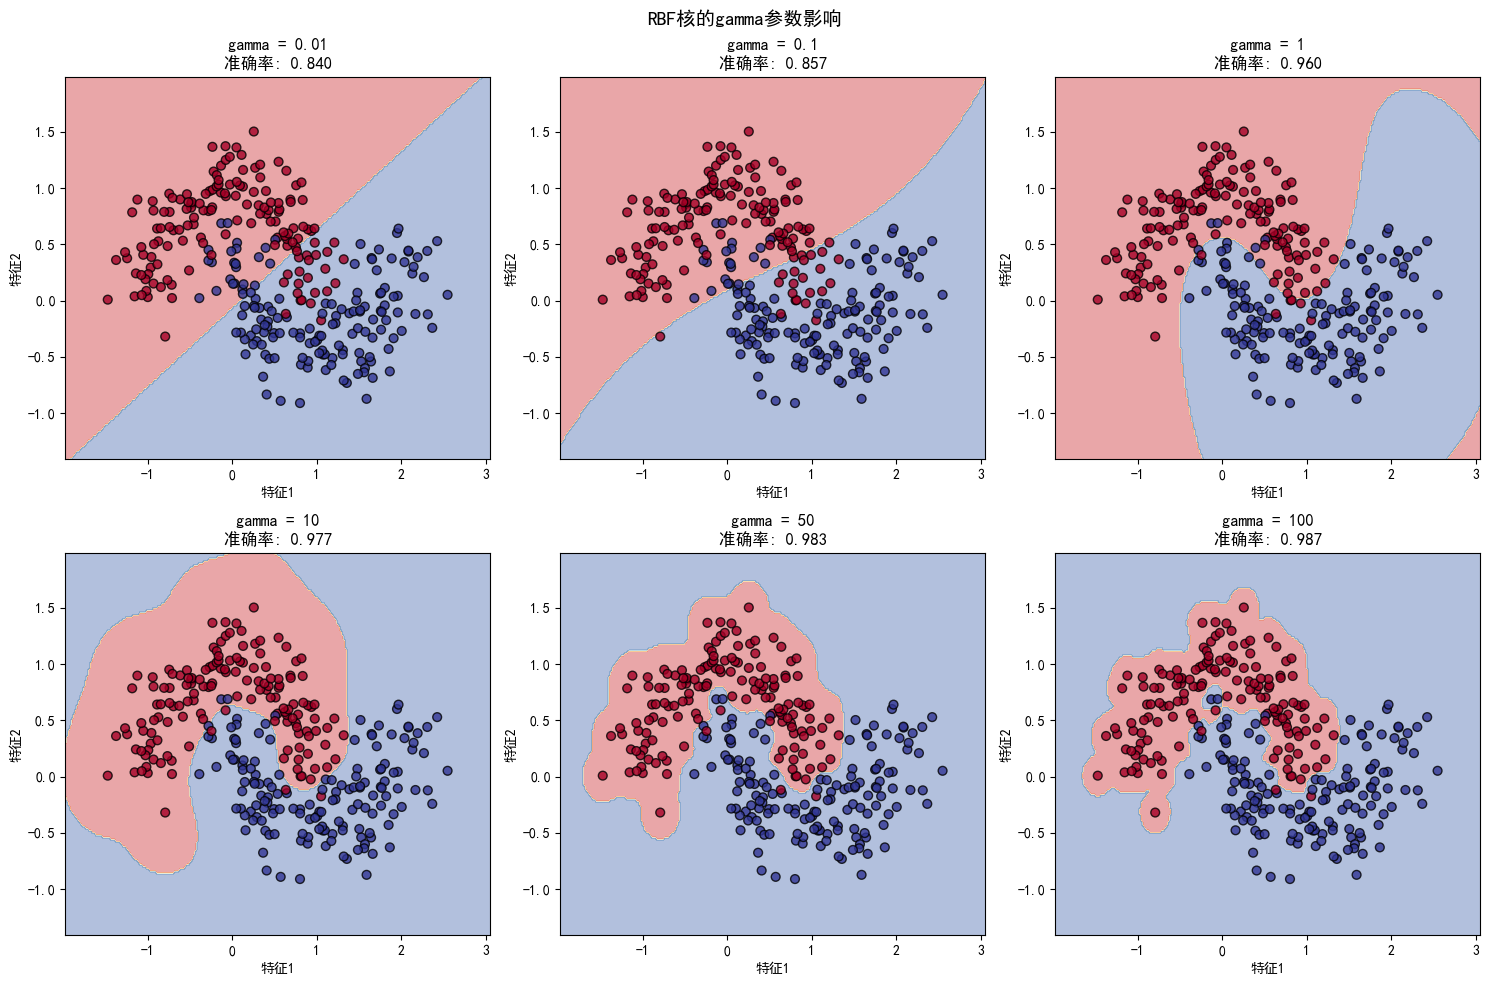


gamma参数总结:
----------------------------------------
gamma小 → 影响范围大 → 决策边界平滑 → 可能欠拟合
gamma大 → 影响范围小 → 决策边界复杂 → 可能过拟合


In [5]:
# gamma参数影响
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
gamma_values = [0.01, 0.1, 1, 10, 50, 100]

for idx, gamma in enumerate(gamma_values):
    ax = axes[idx // 3, idx % 3]
    
    svm = SVC(kernel='rbf', gamma=gamma, C=1.0, random_state=42)
    svm.fit(X_moons, y_moons)
    
    # 绘制决策边界
    h = 0.02
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu', 
              s=40, alpha=0.8, edgecolors='k')
    
    accuracy = svm.score(X_moons, y_moons)
    ax.set_title(f'gamma = {gamma}\n准确率: {accuracy:.3f}')
    ax.set_xlabel('特征1')
    ax.set_ylabel('特征2')

plt.suptitle('RBF核的gamma参数影响', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\ngamma参数总结:")
print("-" * 40)
print("gamma小 → 影响范围大 → 决策边界平滑 → 可能欠拟合")
print("gamma大 → 影响范围小 → 决策边界复杂 → 可能过拟合")


---

## 六、综合实战：鸢尾花分类

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [16]:
print("综合实战：鸢尾花分类")

from sklearn.datasets import load_iris

# 加载数据
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print(f"数据形状: {X_iris.shape}")
print(f"特征名称: {iris.feature_names}")
print(f"类别: {iris.target_names}")

# 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

# 标准化（SVM对特征尺度敏感！）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n标准化后的特征统计:")
print(f"训练集均值: {X_train_scaled.mean(axis=0).round(3)}")
print(f"训练集标准差: {X_train_scaled.std(axis=0).round(3)}")


综合实战：鸢尾花分类
数据形状: (150, 4)
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别: ['setosa' 'versicolor' 'virginica']

标准化后的特征统计:
训练集均值: [-0. -0.  0.  0.]
训练集标准差: [1. 1. 1. 1.]


数据标准化完毕，来试试不同核函数对 SVM 性能的影响：


In [17]:
# 对比不同核函数
from sklearn.metrics import classification_report

kernels = ['linear', 'rbf', 'poly']
results = []

print("\n不同核函数性能对比:")
print("-" * 60)

for kernel in kernels:
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        svm = SVC(kernel=kernel, random_state=42)
    
    svm.fit(X_train_scaled, y_train)
    train_acc = svm.score(X_train_scaled, y_train)
    test_acc = svm.score(X_test_scaled, y_test)
    n_support = len(svm.support_vectors_)
    
    results.append({
        '核函数': kernel,
        '训练准确率': train_acc,
        '测试准确率': test_acc,
        '支持向量数': n_support
    })
    
    print(f"\n{kernel} 核:")
    print(f"  训练准确率: {train_acc:.4f}")
    print(f"  测试准确率: {test_acc:.4f}")
    print(f"  支持向量数: {n_support}")

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print(results_df.to_string(index=False))



不同核函数性能对比:
------------------------------------------------------------

linear 核:
  训练准确率: 0.9750
  测试准确率: 1.0000
  支持向量数: 23

rbf 核:
  训练准确率: 0.9750
  测试准确率: 0.9667
  支持向量数: 47

poly 核:
  训练准确率: 0.9333
  测试准确率: 0.9000
  支持向量数: 46

   核函数    训练准确率    测试准确率  支持向量数
linear 0.975000 1.000000     23
   rbf 0.975000 0.966667     47
  poly 0.933333 0.900000     46


In [ ]:
可以看出：线性核已经足够强，不需要复杂曲线。

核函数对比完毕，再用线性核的权重看看哪些特征最重要：



线性SVM的权重系数:
----------------------------------------

setosa:
  sepal length (cm): -0.453
  sepal width (cm): 0.344
  petal length (cm): -0.868
  petal width (cm): -0.942

versicolor:
  sepal length (cm): -0.062
  sepal width (cm): 0.142
  petal length (cm): -0.554
  petal width (cm): -0.557

virginica:
  sepal length (cm): 0.228
  sepal width (cm): 0.345
  petal length (cm): -1.890
  petal width (cm): -2.153


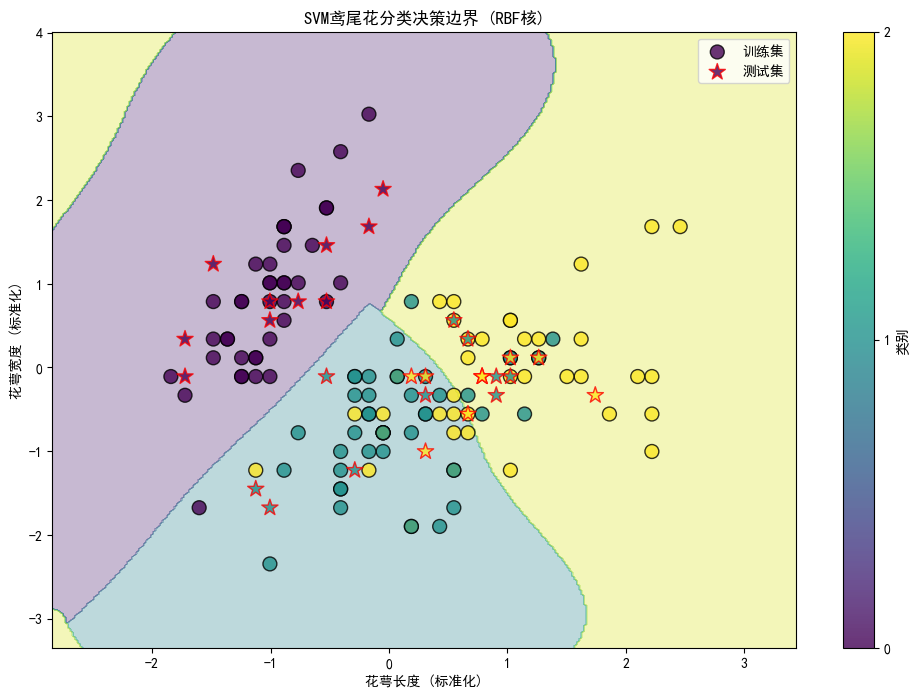


2D特征测试准确率: 0.7333


In [18]:
# 可视化特征重要性（使用线性核的系数）
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# 对于多分类，每个类别有一个分类器
coef = svm_linear.coef_
print("\n线性SVM的权重系数:")
print("-" * 40)
for i, class_name in enumerate(iris.target_names):
    print(f"\n{class_name}:")
    for j, feature_name in enumerate(iris.feature_names):
        print(f"  {feature_name}: {coef[i, j]:.3f}")

# 可视化决策边界（使用前两个特征）
X_2d = X_iris[:, :2]  # 只用花萼长度和宽度
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# 绘制决策边界
plt.figure(figsize=(12, 8))

h = 0.02
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], 
                     c=y_train_2d, cmap='viridis', s=100, alpha=0.8, 
                     edgecolors='k', label='训练集')
plt.scatter(X_test_2d_scaled[:, 0], X_test_2d_scaled[:, 1], 
           c=y_test_2d, cmap='viridis', s=150, alpha=0.8, 
           edgecolors='r', marker='*', label='测试集')

plt.xlabel('花萼长度 (标准化)')
plt.ylabel('花萼宽度 (标准化)')
plt.title('SVM鸢尾花分类决策边界 (RBF核)')
plt.legend()
plt.colorbar(scatter, ticks=[0, 1, 2], label='类别')
plt.show()

print(f"\n2D特征测试准确率: {svm_2d.score(X_test_2d_scaled, y_test_2d):.4f}")


---

## 七、SVM的优缺点与适用场景

SVM 不是万能的，知道它擅长什么、不擅长什么才不会用错：

✅ 优点：
1. 泛化能力强，不容易过拟合
2. 在高维数据上表现好
3. 决策边界只依赖支持向量，内存高效
4. 可以通过核函数处理非线性问题
5. 有坚实的数学理论基础

❌ 缺点：
1. 大数据集训练慢（O(n²)到O(n³)）
2. 对噪声敏感（支持向量容易受影响）
3. 核函数和参数选择需要经验
4. 不直接提供概率输出（需要校准）
5. 多分类需要组合多个二分类器

🎯 适用场景：
- 特征维度高、样本量中等的数据
- 文本分类（高维稀疏特征）
- 图像识别（配合特定核函数）
- 生物信息学（基因表达数据）
- 需要强泛化能力的场景

⚠️ 不适用场景：
- 样本量极大（>10万）的数据集
- 需要快速预测/训练的场景
- 特征数远大于样本数且噪声多

---

## 八、小结

| 概念 | 说明 |
|------|------|
| **支持向量** | 决定分类边界的样本点 |
| **间隔** | 分类边界到最近点的距离 |
| **C参数** | 控制软硬间隔的权衡 |
| **核函数** | 将数据映射到高维空间的技巧 |
| **gamma** | RBF核的影响范围参数 |

**SVM vs 随机森林 vs 决策树**：

| 特性 | 决策树 | 随机森林 | SVM |
|------|--------|----------|-----|
| 训练速度 | 快 | 中等 | 慢 |
| 预测速度 | 快 | 中等 | 中等 |
| 可解释性 | 强 | 中等 | 弱 |
| 高维数据 | 一般 | 好 | 很好 |
| 需要标准化 | 否 | 否 | **是** |
| 处理非线性 | 可以 | 可以 | 核函数 |

---

## 九、课后练习

1. 尝试不同的C值组合，观察对鸢尾花分类的影响
2. 对比标准化前后SVM的性能差异
3. 用SVM完成一个二分类任务（如垃圾邮件识别）
4. 思考：为什么SVM对特征尺度敏感？

练习1：不同C值对鸢尾花分类的影响
  C=  0.01: 训练准确率=0.5048, 测试准确率=0.3556
  C=  0.10: 训练准确率=0.7905, 测试准确率=0.7778
  C=  1.00: 训练准确率=0.7905, 测试准确率=0.7333
  C= 10.00: 训练准确率=0.8095, 测试准确率=0.7778
  C=100.00: 训练准确率=0.8000, 测试准确率=0.8222


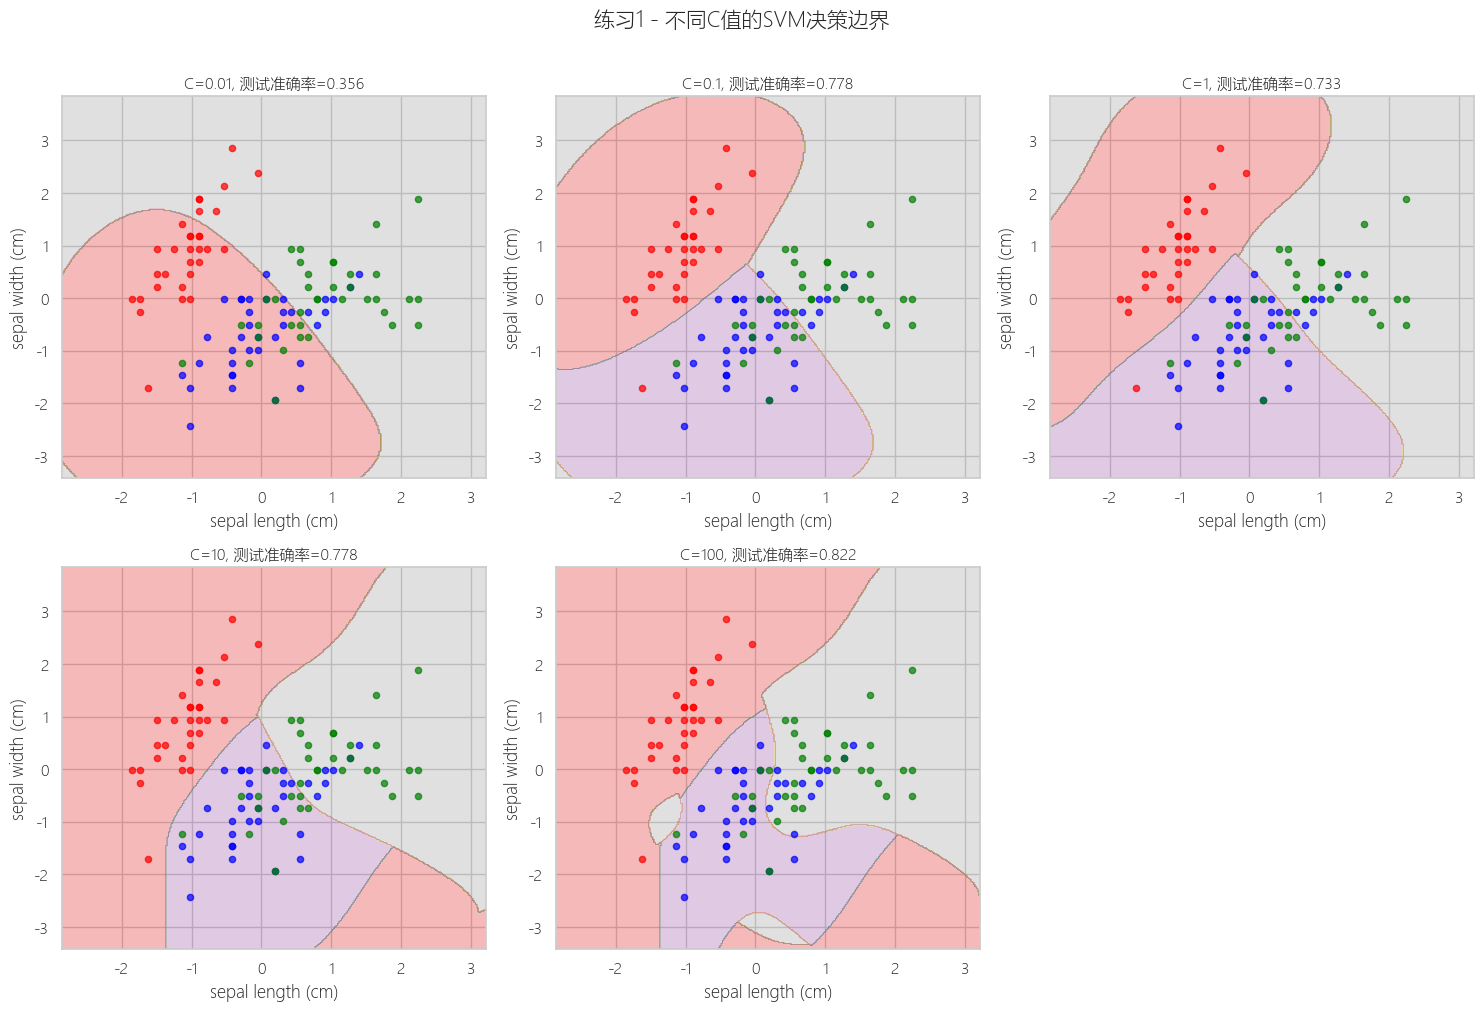

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score)
from sklearn.svm import SVC

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 练习1：尝试不同的C值，观察对鸢尾花分类的影响
# ============================================================
print("=" * 60)
print("练习1：不同C值对鸢尾花分类的影响")
print("=" * 60)

iris = load_iris()
X, y = iris.data, iris.target

# 只用前两个特征便于可视化
X_2d = X[:, :2]
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42)

# 标准化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

C_values = [0.01, 0.1, 1, 10, 100]
train_accs = []
test_accs = []

for C in C_values:
    svm = SVC(C=C, kernel='rbf', random_state=42)
    svm.fit(X_train_s, y_train)
    train_acc = svm.score(X_train_s, y_train)
    test_acc = svm.score(X_test_s, y_test)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"  C={C:>6.2f}: 训练准确率={train_acc:.4f}, 测试准确率={test_acc:.4f}")

# 可视化：不同C值的决策边界
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, C in enumerate(C_values):
    ax = axes[idx]
    svm = SVC(C=C, kernel='rbf', random_state=42)
    svm.fit(X_train_s, y_train)

    # 绘制决策边界
    h = 0.02
    x_min, x_max = X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1
    y_min, y_max = X_train_s[:, 1].min() - 1, X_train_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    for i, color in zip([0, 1, 2], ['red', 'blue', 'green']):
        ax.scatter(X_train_s[y_train == i, 0], X_train_s[y_train == i, 1],
                   c=color, label=iris.target_names[i], alpha=0.7, s=20)

    test_acc = svm.score(X_test_s, y_test)
    ax.set_title(f'C={C}, 测试准确率={test_acc:.3f}', fontsize=11)
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])

axes[-1].axis('off')
fig.suptitle('练习1 - 不同C值的SVM决策边界', fontsize=15, y=1.01)
plt.tight_layout()

In [2]:
# ============================================================
# 练习2：对比标准化前后SVM的性能差异
# ============================================================
print("\n" + "=" * 60)
print("练习2：标准化前后SVM性能对比")
print("=" * 60)

# 使用全部4个特征
X_full, y_full = iris.data, iris.target
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# 故意制造尺度差异
X_train_dirty = X_train_f.copy()
X_test_dirty = X_test_f.copy()
X_train_dirty[:, 0] *= 100  # 放大第一个特征
X_test_dirty[:, 0] *= 100

# 未标准化
svm_raw = SVC(kernel='rbf', C=1.0, random_state=42)
svm_raw.fit(X_train_dirty, y_train_f)
acc_raw = svm_raw.score(X_test_dirty, y_test_f)
print(f"  未标准化准确率: {acc_raw:.4f}")

# 标准化后
scaler = StandardScaler()
X_train_clean = scaler.fit_transform(X_train_dirty)
X_test_clean = scaler.transform(X_test_dirty)

svm_scaled = SVC(kernel='rbf', C=1.0, random_state=42)
svm_scaled.fit(X_train_clean, y_train_f)
acc_scaled = svm_scaled.score(X_test_clean, y_test_f)
print(f"  标准化后准确率: {acc_scaled:.4f}")
print(f"  提升: {acc_scaled - acc_raw:.4f}")

# 同时对比不同C值
print(f"\n不同C值下标准化前后对比:")
C_compare = [0.1, 1, 10]
for C in C_compare:
    svm1 = SVC(C=C, random_state=42).fit(X_train_dirty, y_train_f)
    svm2 = SVC(C=C, random_state=42).fit(X_train_clean, y_train_f)
    a1 = svm1.score(X_test_dirty, y_test_f)
    a2 = svm2.score(X_test_clean, y_test_f)
    print(f"  C={C:>4.1f}: 原始={a1:.4f}, 标准化={a2:.4f}, 差={a2-a1:+.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(C_compare))
w = 0.35
raw_scores = [SVC(C=C, random_state=42).fit(X_train_dirty, y_train_f).score(X_test_dirty, y_test_f) for C in C_compare]
scaled_scores = [SVC(C=C, random_state=42).fit(X_train_clean, y_train_f).score(X_test_clean, y_test_f) for C in C_compare]
ax.bar(x - w/2, raw_scores, w, label='未标准化', color='coral', alpha=0.8)
ax.bar(x + w/2, scaled_scores, w, label='标准化后', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'C={C}' for C in C_compare])
ax.set_title('练习2 - 标准化前后SVM性能对比', fontsize=14)
ax.set_ylabel('准确率', fontsize=12)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.close()



练习2：标准化前后SVM性能对比
  未标准化准确率: 0.7111
  标准化后准确率: 1.0000
  提升: 0.2889

不同C值下标准化前后对比:
  C= 0.1: 原始=0.4222, 标准化=0.9333, 差=+0.5111
  C= 1.0: 原始=0.7111, 标准化=1.0000, 差=+0.2889
  C=10.0: 原始=0.7111, 标准化=0.9778, 差=+0.2667


In [3]:
# ============================================================
# 练习3：用SVM完成一个二分类任务
# ============================================================
print("\n" + "=" * 60)
print("练习3：SVM二分类任务")
print("=" * 60)

X_bin, y_bin = make_classification(n_samples=500, n_features=10, n_informative=5,
                                    n_redundant=2, random_state=42)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.3, random_state=42)

scaler_b = StandardScaler()
X_train_bs = scaler_b.fit_transform(X_train_b)
X_test_bs = scaler_b.transform(X_test_b)

# 对比不同kernel
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
print(f"\n不同kernel的SVM性能:")
for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_train_bs, y_train_b)
    y_pred = svm.predict(X_test_bs)
    acc = accuracy_score(y_test_b, y_pred)
    f1 = f1_score(y_test_b, y_pred)
    print(f"  kernel={kernel:>8s}: 准确率={acc:.4f}, F1={f1:.4f}")

# 最佳kernel的详细报告
best_kernel = 'rbf'
svm_best = SVC(kernel=best_kernel, C=1.0, random_state=42)
svm_best.fit(X_train_bs, y_train_b)
y_pred_best = svm_best.predict(X_test_bs)
print(f"\n最佳kernel({best_kernel})的分类报告:")
print(classification_report(y_test_b, y_pred_best))

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
kernel_accs = [accuracy_score(y_test_b, SVC(kernel=k, random_state=42).fit(X_train_bs, y_train_b).predict(X_test_bs)) for k in kernels]
bars = ax.bar(kernels, kernel_accs, color='steelblue', alpha=0.8, edgecolor='gray')
for bar, v in zip(bars, kernel_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('练习3 - 不同kernel的SVM准确率', fontsize=14)
ax.set_ylabel('准确率', fontsize=12)
ax.set_ylim(min(kernel_accs) - 0.05, 1.05)
plt.tight_layout()
plt.close()


练习3：SVM二分类任务

不同kernel的SVM性能:
  kernel=  linear: 准确率=0.8067, F1=0.8129
  kernel=     rbf: 准确率=0.9067, F1=0.9136
  kernel=    poly: 准确率=0.8467, F1=0.8497
  kernel= sigmoid: 准确率=0.7600, F1=0.7662

最佳kernel(rbf)的分类报告:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        68
           1       0.93      0.90      0.91        82

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



   1. SVM的核心是寻找"最大间隔超平面"，间隔的计算基于样本到超平面的距离：
      距离 = |w·x + b| / ||w||

   2. 如果特征的尺度差异很大（例如一个特征范围[0,1]，另一个[0,10000]）：
      - 大尺度特征会在距离计算中占主导地位
      - 模型基本只根据大尺度特征来做决策，忽略了小尺度特征
      - 这导致间隔超平面偏向大尺度特征，降低了模型性能

   3. 对于RBF核：核函数 K(x, y) = exp(-γ||x-y||²)
      - 距离 ||x-y||² 受大尺度特征主导
      - 大尺度特征会使所有样本的距离看起来都很大
      - 导致γ参数的效果被扭曲

   4. C参数的影响：
      - 未标准化时，C对大尺度特征的约束效果更强
      - 标准化后，C对所有特征一视同仁

   5. 解决方案：
      - StandardScaler：将每个特征变为均值0、标准差1
      - MinMaxScaler：将每个特征缩放到[0,1]范围
      - 这是SVM建模前必须做的预处理步骤

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 52 篇：K 近邻 KNN — 最直觉的分类算法**
>
> 下篇学 K 近邻——最直觉的分类算法，核心思想是「近朱者赤，近墨者黑」，看邻居是谁来判断类别。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*